# 可选实验 - 多分类


## 1.1 目标
在本实验中，你将探索使用神经网络进行多分类的示例。
<figure>
 <img src="./images/C2_W2_mclass_header.png"   style="width500px;height:200px;">
</figure>


## 1.2 工具
你将使用一些绘图例程。这些例程存储在本目录的 `lab_utils_multiclass_TF.py` 文件中。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
from sklearn.datasets import make_blobs
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
np.set_printoptions(precision=2)
from lab_utils_multiclass_TF import *
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

I0000 00:00:1781450143.129846   40012 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781450143.180162   40012 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781450144.200748   40012 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# 2.0 多分类
神经网络常用于分类数据。例如：
- 输入照片并将照片中的主体分类为 {狗,猫,马,其他}
- 输入一个句子并对其元素进行'词性'分类：{名词, 动词, 形容词等}  

这种类型的网络在其最后一层有多个单元。每个输出对应一个类别。当输入样本被送入网络时，具有最高值的输出就是预测的类别。如果输出经过softmax函数处理，softmax的输出将提供输入属于每个类别的概率。

在本实验中，你将看到在Tensorflow中构建多分类网络的示例。然后我们将看看神经网络如何进行预测。

让我们从创建一个四分类数据集开始。

## 2.1 准备和可视化数据
我们将使用Scikit-Learn的 `make_blobs` 函数来创建一个包含4个类别的训练数据集，如下图所示。

In [2]:
# 创建4类分类数据集
classes = 4
m = 100
centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]
std = 1.0
X_train, y_train = make_blobs(n_samples=m, centers=centers, cluster_std=std,random_state=30)

/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 2/Labs/lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nb

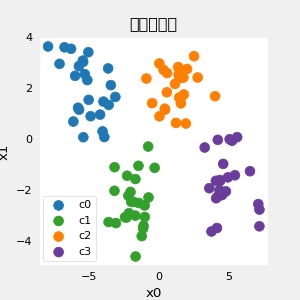

In [3]:
plt_mc(X_train,y_train,classes, centers, std=std)

每个点代表一个训练样本。坐标轴 (x0,x1) 是输入，颜色代表样本所属的类别。训练完成后，模型将接收新样本 (x0,x1) 并预测其类别。  

虽然是生成的，但这个数据集代表了许多现实世界的分类问题。有多个输入特征 (x0,...,xn) 和多个输出类别。模型被训练来使用输入特征预测正确的输出类别。

In [4]:
# 显示数据集中的类别
print(f"unique classes {np.unique(y_train)}")
# 显示类别的表示方式
print(f"class representation {y_train[:10]}")
# 显示数据集的形状
print(f"shape of X_train: {X_train.shape}, shape of y_train: {y_train.shape}")

unique classes [0 1 2 3]
class representation [3 3 3 0 3 3 3 3 2 0]
shape of X_train: (100, 2), shape of y_train: (100,)


## 2.2 模型
<img align="Right" src="./images/C2_W2_mclass_lab_network.PNG"  style=" width:350px; padding: 10px 20px ; ">
本实验将使用如图所示的2层网络。
与二分类网络不同，这个网络有四个输出，每个类别一个。给定一个输入样本，具有最高值的输出就是输入的预测类别。  

下面是如何在Tensorflow中构建此网络的示例。注意输出层使用 `linear` 而不是 `softmax` 激活函数。虽然可以在输出层中包含softmax，但如果在训练期间将线性输出传递给损失函数，数值上会更稳定。如果模型用于预测概率，可以在那时应用softmax。

In [5]:
tf.random.set_seed(1234)  # 设置随机种子以获得一致的结果
model = Sequential(
    [
        Dense(2, activation = 'relu',   name = "L1"),
        Dense(4, activation = 'linear', name = "L2")
    ]
)

下面的语句编译并训练网络。将 `from_logits=True` 设置为损失函数的参数，指定输出激活是线性的而不是softmax。

In [6]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)

model.fit(
    X_train,y_train,
    epochs=200
)

W0000 00:00:1781450145.354086   40012 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9292  
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7677 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6391 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5318 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4429 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3694 
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3083 
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2540 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2018 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1505 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0999 
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0504 
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0029 
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9588 
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9189 
Epoch 16/200
4/4 ━

模型训练完成后，我们可以看到模型如何对训练数据进行分类。

184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step


/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 367

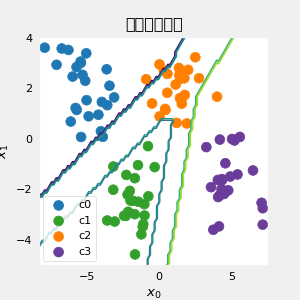

In [7]:
plt_cat_mc(X_train, y_train, model, classes)

上面的决策边界显示了模型如何划分输入空间。这个非常简单的模型在分类训练数据时没有遇到任何困难。它是如何做到的？让我们更详细地看看网络。

下面，我们将从模型中提取训练好的权重，并用它来绘制每个网络单元的函数。再下面是结果的更详细解释。你不需要知道这些细节就能成功使用神经网络，但了解层如何组合来解决分类问题可能会有所帮助。

In [8]:
# 从第一层获取训练好的参数
l1 = model.get_layer("L1")
W1,b1 = l1.get_weights()

/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 2/Labs/lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 2/Labs/lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 2/Labs/lab_utils_multiclass_TF.py:157: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 2/Labs/lab_utils_multiclass_TF.py:157: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/workspaces/andrewNG/Cou

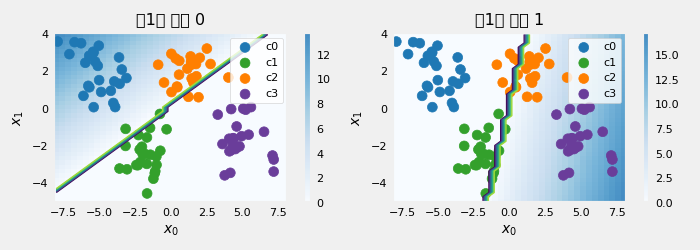

In [9]:
# 绘制第一层的函数
plt_layer_relu(X_train, y_train.reshape(-1,), W1, b1, classes)

/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 2/Labs/lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 2/Labs/lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 2/Labs/lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 2/Labs/lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatt

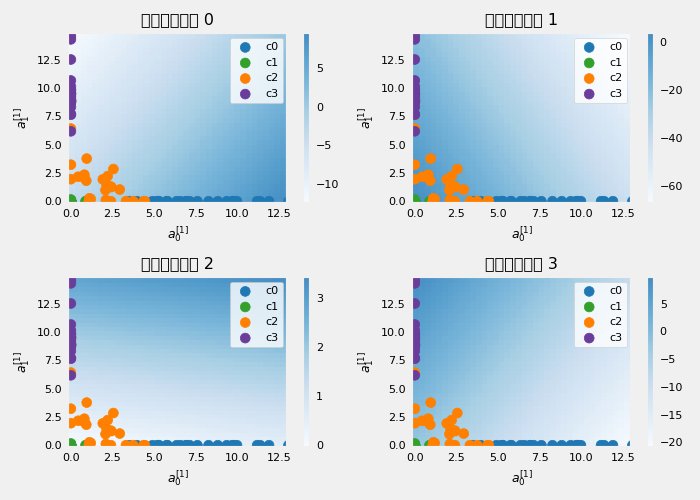

In [10]:
# 从输出层获取训练好的参数
l2 = model.get_layer("L2")
W2, b2 = l2.get_weights()
# 创建'新特征'，即经过L1变换后的训练样本
Xl2 = np.maximum(0, np.dot(X_train,W1) + b1)

plt_output_layer_linear(Xl2, y_train.reshape(-1,), W2, b2, classes,
                        x0_rng = (-0.25,np.amax(Xl2[:,0])), x1_rng = (-0.25,np.amax(Xl2[:,1])))

## 解释
#### 第1层 <img align="Right" src="./images/C2_W2_mclass_layer1.png"  style=" width:600px; padding: 10px 20px ; ">
这些图显示了网络第一层中单元0和1的函数。输入是坐标轴上的 ($x_0,x_1$)。单元的输出由背景颜色表示。这由每个图右侧的颜色条指示。注意，由于这些单元使用ReLU，输出不一定在0和1之间，在这种情况下峰值大于20。
图中的等高线显示了输出 $a^{[1]}_j$ 为零和非零之间的过渡点。回顾ReLU的图：<img align="right" src="./images/C2_W2_mclass_relu.png"  style=" width:200px; padding: 10px 20px ; "> 图中的等高线是ReLU的拐点。

单元0将类别0和1与类别2和3分开。线左侧的点（类别0和1）将输出零，而右侧的点将输出大于零的值。  
单元1将类别0和2与类别1和3分开。线以上的点（类别0和2）将输出零，而线以下的点将输出大于零的值。让我们在下一层看看这是如何工作的！

#### 第2层，输出层  <img align="Right" src="./images/C2_W2_mclass_layer2.png"  style=" width:600px; padding: 10px 20px ; ">

这些图中的点是经过第一层变换的训练样本。一种理解方式是，第一层为第二层创建了一组新的特征用于评估。这些图的坐标轴是前一层的输出 $a^{[1]}_0$ 和 $a^{[1]}_1$。正如上面预测的，类别0和1（蓝色和绿色）的 $a^{[1]}_0 = 0$，而类别0和2（蓝色和橙色）的 $a^{[1]}_1 = 0$。  
同样，背景颜色的强度表示最高值。  
单元0将在 (0,0) 附近产生最大值，类别0（蓝色）已被映射到此处。    
单元1在左上角产生最高值，选择类别1（绿色）。  
单元2针对右下角的类别2（橙色）。  
单元3在右上角产生最高值，选择我们的最后一个类别（紫色）。  

从图中不太明显的一点是，这些值在各单元之间已经进行了协调。一个单元为其选择的类别产生最大值是不够的，它还必须是该类别中所有单元的最高值。这是通过损失函数（`SparseCategoricalCrossEntropy`）中隐含的softmax函数完成的。与其他激活函数不同，softmax跨越所有输出工作。

你可以在不知道每个单元具体做什么的情况下成功使用神经网络。希望这个例子能让你对底层发生的事情有一些直观的理解。

## 恭喜！
你已经学会了构建和运行用于多分类的神经网络。
